In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('cleaned_amazon_reviews.csv')

# Display the first few rows
df.head()

,product_id,product_name,category,discounted_price,actual_price,discount_percentage,rating,rating_count,about_product,user_id,user_name,review_id,review_title,review_content,img_link,product_link
0,B07JW9H4J1,Wayona Nylon Braided USB to Lightning Fast Cha...,Computers&Accessories|Accessories&Peripherals|...,399.0,1099.0,64,4.2,24269.0,High Compatibility : Compatible With iPhone 12...,"AG3D6O4STAQKAY2UVGEUV46KN35Q,AHMY5CWJMMK5BJRBB...","Manav,Adarsh gupta,Sundeep,S.Sayeed Ahmed,jasp...","R3HXWT0LRP0NMF,R2AJM3LFTLZHFO,R6AQJGUP6P86,R1K...","Satisfied,Charging is really fast,Value for mo...",Looks durable Charging is fine tooNo complains...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Wayona-Braided-WN3LG1-Sy...
1,B098NS6PVG,Ambrane Unbreakable 60W / 3A Fast Charging 1.5...,Computers&Accessories|Accessories&Peripherals|...,199.0,349.0,43,4.0,43994.0,"Compatible with all Type C enabled devices, be...","AECPFYFQVRUWC3KGNLJIOREFP5LQ,AGYYVPDD7YG7FYNBX...","ArdKn,Nirbhay kumar,Sagar Viswanathan,Asp,Plac...","RGIQEG07R9HS2,R1SMWZQ86XIN8U,R2J3Y1WL29GWDE,RY...","A Good Braided Cable for Your Type C Device,Go...",I ordered this cable to connect my phone to An...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Ambrane-Unbreakable-Char...
2,B096MSW6CT,Sounce Fast Phone Charging Cable & Data Sync U...,Computers&Accessories|Accessories&Peripherals|...,199.0,1899.0,90,3.9,7928.0,【 Fast Charger& Data Sync】-With built-in safet...,"AGU3BBQ2V2DDAMOAKGFAWDDQ6QHA,AESFLDV2PT363T2AQ...","Kunal,Himanshu,viswanath,sai niharka,saqib mal...","R3J3EQQ9TZI5ZJ,R3E7WBGK7ID0KV,RWU79XKQ6I1QF,R2...","Good speed for earlier versions,Good Product,W...","Not quite durable and sturdy,https://m.media-a...",https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Sounce-iPhone-Charging-C...
3,B08HDJ86NZ,boAt Deuce USB 300 2 in 1 Type-C & Micro USB S...,Computers&Accessories|Accessories&Peripherals|...,329.0,699.0,53,4.2,94363.0,The boAt Deuce USB 300 2 in 1 cable is compati...,"AEWAZDZZJLQUYVOVGBEUKSLXHQ5A,AG5HTSFRRE6NL3M5S...","Omkar dhale,JD,HEMALATHA,Ajwadh a.,amar singh ...","R3EEUZKKK9J36I,R3HJVYCLYOY554,REDECAZ7AMPQC,R1...","Good product,Good one,Nice,Really nice product...","Good product,long wire,Charges good,Nice,I bou...",https://m.media-amazon.com/images/I/41V5FtEWPk...,https://www.amazon.in/Deuce-300-Resistant-Tang...
4,B08CF3B7N1,Portronics Konnect L 1.2M Fast Charging 3A 8 P...,Computers&Accessories|Accessories&Peripherals|...,154.0,399.0,61,4.2,16905.0,[CHARGE & SYNC FUNCTION]- This cable comes wit...,"AE3Q6KSUK5P75D5HFYHCRAOLODSA,AFUGIFH5ZAFXRDSZH...","rahuls6099,Swasat Borah,Ajay Wadke,Pranali,RVK...","R1BP4L2HH9TFUP,R16PVJEXKV6QZS,R2UPDB81N66T4P,R...","As good as original,Decent,Good one for second...","Bought this instead of original apple, does th...",https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Portronics-Konnect-POR-1...


In [6]:
# Check for missing values
print(df.isnull().sum())



product_id             0
product_name           0
category               0
discounted_price       0
actual_price           0
discount_percentage    0
rating                 0
rating_count           0
about_product          0
user_id                0
user_name              0
review_id              0
review_title           0
review_content         0
img_link               0
product_link           0
dtype: int64


In [7]:
# Check data types
print(df.dtypes)


product_id              object
product_name            object
category                object
discounted_price       float64
actual_price           float64
discount_percentage      int64
rating                 float64
rating_count           float64
about_product           object
user_id                 object
user_name               object
review_id               object
review_title            object
review_content          object
img_link                object
product_link            object
dtype: object


In [8]:

# Check for duplicates
print(f"Number of duplicate rows: {df.duplicated().sum()}")



Number of duplicate rows: 0


In [9]:
# Convert relevant columns to appropriate types if needed
df['discounted_price'] = df['discounted_price'].astype(float)
df['actual_price'] = df['actual_price'].astype(float)
df['discount_percentage'] = df['discount_percentage'].astype(int)
df['rating'] = pd.to_numeric(df['rating'], errors='coerce')
df['rating_count'] = pd.to_numeric(df['rating_count'], errors='coerce')



In [10]:
# Handle missing values (if any)
df['rating'].fillna(df['rating'].median(), inplace=True)
df['rating_count'].fillna(df['rating_count'].median(), inplace=True)

C:\Users\HARSHIT SHARMA\AppData\Local\Temp\ipykernel_4272\928004057.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['rating'].fillna(df['rating'].median(), inplace=True)
C:\Users\HARSHIT SHARMA\AppData\Local\Temp\ipykernel_4272\928004057.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behav

In [11]:
# Descriptive statistics
print(df[['discounted_price', 'actual_price', 'discount_percentage', 'rating', 'rating_count']].describe())

       discounted_price   actual_price  discount_percentage       rating  \
count       1462.000000    1462.000000          1462.000000  1462.000000   
mean        3129.981826    5453.087743            47.672367     4.096717   
std         6950.548042   10884.467444            21.613905     0.289497   
min           39.000000      39.000000             0.000000     2.000000   
25%          325.000000     800.000000            32.000000     4.000000   
50%          799.000000    1670.000000            50.000000     4.100000   
75%         1999.000000    4321.250000            63.000000     4.300000   
max        77990.000000  139900.000000            94.000000     5.000000   

        rating_count  
count    1462.000000  
mean    18307.376881  
std     42766.096572  
min         2.000000  
25%      1191.500000  
50%      5179.000000  
75%     17342.250000  
max    426973.000000  


In [12]:
# Split the category column (since it contains hierarchical categories separated by '|')
df['main_category'] = df['category'].apply(lambda x: x.split('|')[0])
category_counts = df['main_category'].value_counts()

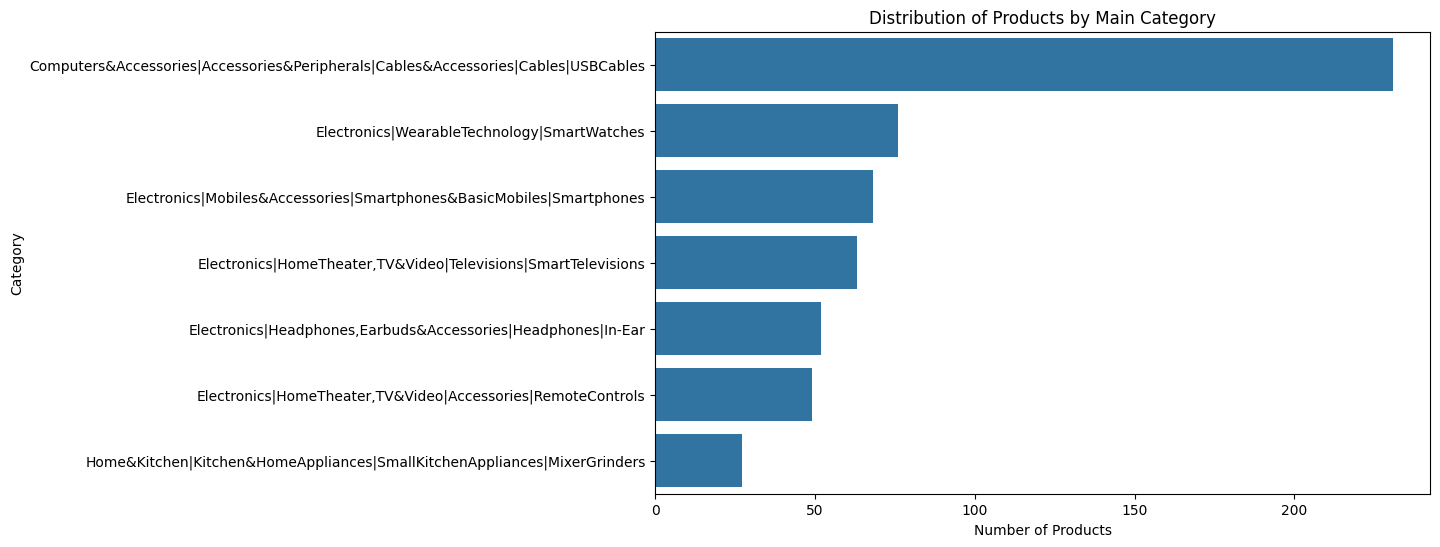

In [15]:
# Plot category distribution
plt.figure(figsize=(10, 6))
sns.barplot(x=category_counts.values, y=category_counts.index)
plt.title('Distribution of Products by Main Category')
plt.xlabel('Number of Products')
plt.ylabel('Category')
plt.show()

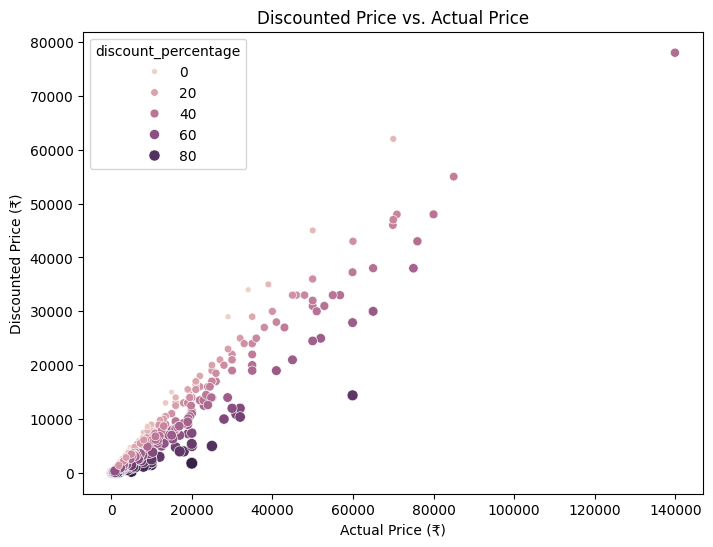

In [19]:
# Scatter plot of discounted price vs. actual price
plt.figure(figsize=(8, 6))
sns.scatterplot(x='actual_price', y='discounted_price', hue='discount_percentage', size='discount_percentage', data=df)
plt.title('Discounted Price vs. Actual Price')
plt.xlabel('Actual Price (₹)')
plt.ylabel('Discounted Price (₹)')
plt.show()



In [21]:
# # Get top 10 products by discount percentage
# top_10_discounts = df.sort_values(by='discount_percentage', ascending=False).head(10)

# # Scatter plot for top 10 discounted products
# plt.figure(figsize=(8, 6))
# sns.scatterplot(
#     x='actual_price',
#     y='discounted_price',
#     hue='discount_percentage',
#     size='discount_percentage',
#     data=top_10_discounts,
#     palette='cool',
#     legend='full'
# )

# plt.title('Top 10 Products with Highest Discount')
# plt.xlabel('Actual Price (₹)')
# plt.ylabel('Discounted Price (₹)')
# plt.tight_layout()
# plt.show()

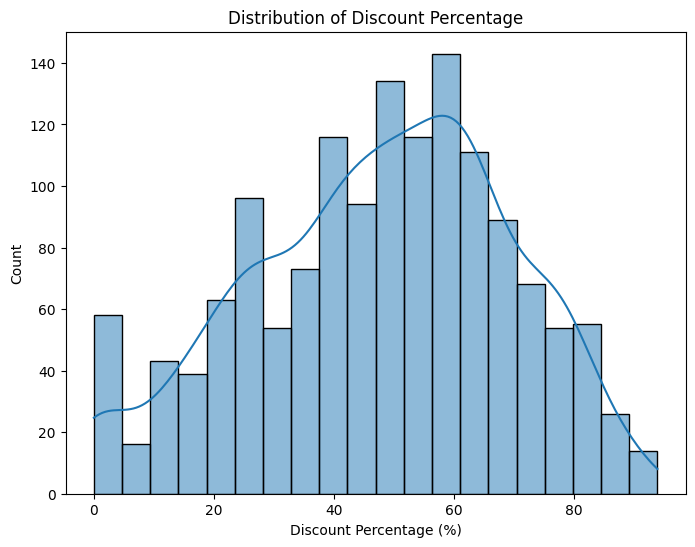

In [22]:
# Distribution of discount percentage
plt.figure(figsize=(8, 6))
sns.histplot(df['discount_percentage'], bins=20, kde=True)
plt.title('Distribution of Discount Percentage')
plt.xlabel('Discount Percentage (%)')
plt.ylabel('Count')
plt.show()

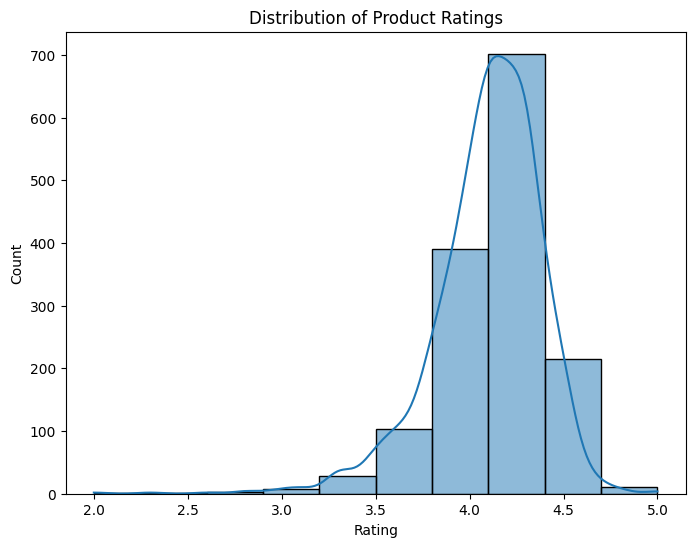

In [23]:
# Distribution of ratings
plt.figure(figsize=(8, 6))
sns.histplot(df['rating'], bins=10, kde=True)
plt.title('Distribution of Product Ratings')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.show()

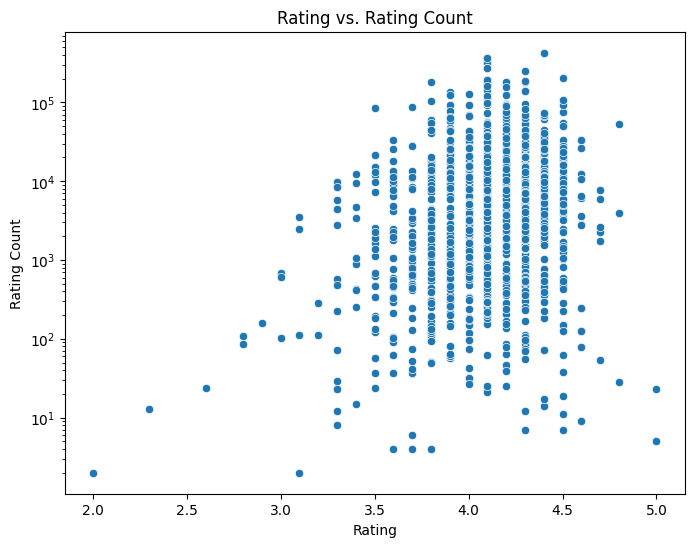

In [24]:
# Rating vs. Rating Count
plt.figure(figsize=(8, 6))
sns.scatterplot(x='rating', y='rating_count', data=df)
plt.title('Rating vs. Rating Count')
plt.xlabel('Rating')
plt.ylabel('Rating Count')
plt.yscale('log')  # Log scale for better visualization
plt.show()

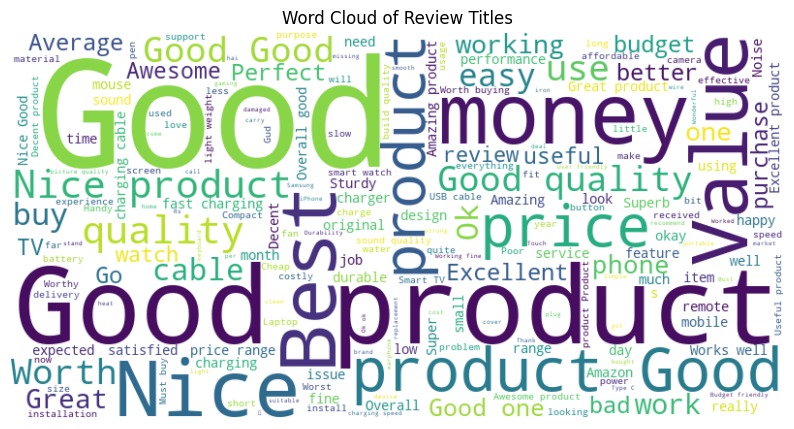

In [25]:
from wordcloud import WordCloud

# Combine review titles for word cloud
reviews_text = ' '.join(df['review_title'].dropna().astype(str))

# Generate word cloud
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(reviews_text)
plt.figure(figsize=(10, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud of Review Titles')
plt.show()

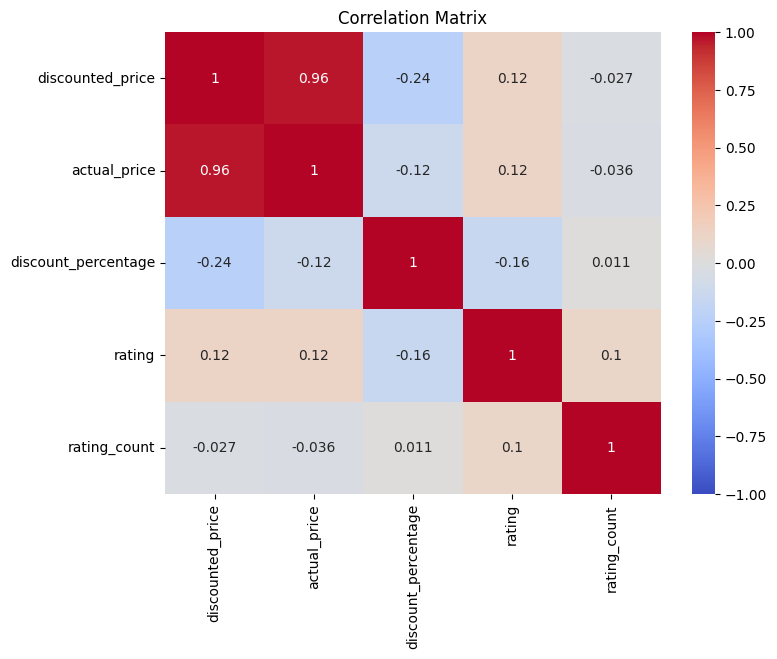

In [26]:
# Correlation matrix
corr = df[['discounted_price', 'actual_price', 'discount_percentage', 'rating', 'rating_count']].corr()

# Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Matrix')
plt.show()

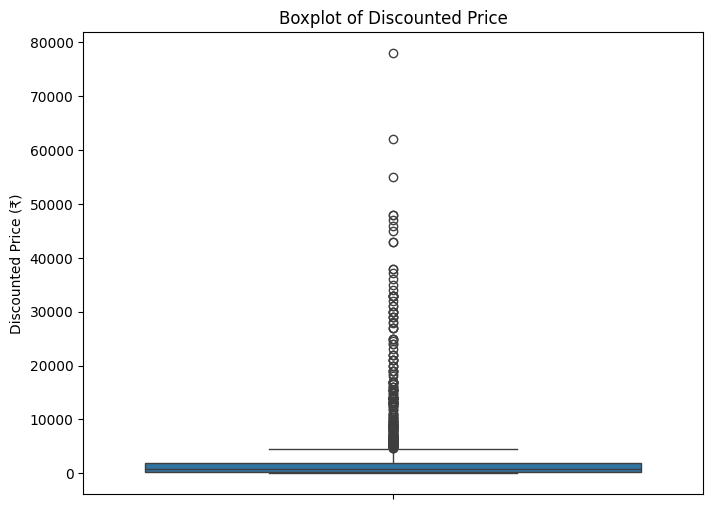

In [27]:
# Boxplot for discounted price
plt.figure(figsize=(8, 6))
sns.boxplot(y=df['discounted_price'])
plt.title('Boxplot of Discounted Price')
plt.ylabel('Discounted Price (₹)')
plt.show()

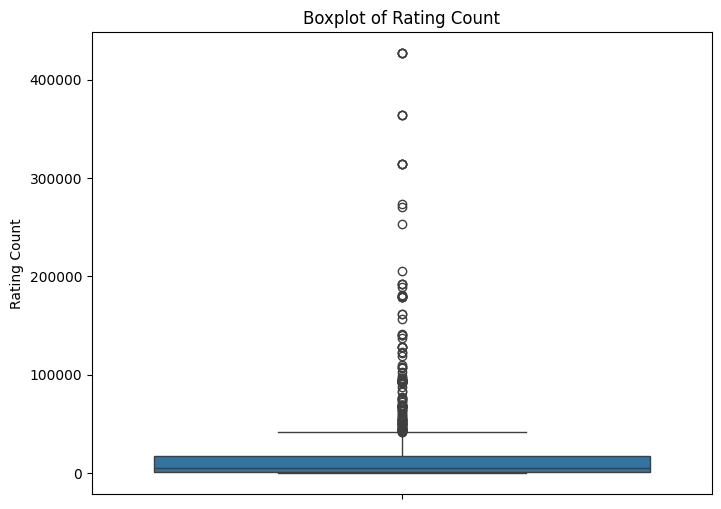

In [28]:
# Boxplot for rating count
plt.figure(figsize=(8, 6))
sns.boxplot(y=df['rating_count'])
plt.title('Boxplot of Rating Count')
plt.ylabel('Rating Count')
plt.show()

In [30]:
df.to_csv("Pandas4_Eda.csv", index=False)
